In [1]:
!pip install shap feature-engine -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 9.5 MB/s eta 0:00:00


This is an EDA of Indian JOB Market for 2027. First, we would be importing the libraries of python that are gonna be handy for us

In [2]:
import pandas as pd
import numpy as np
import re, warnings
warnings.filterwarnings('ignore')

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110

# ── Modelling ────────────────────────────────────────
from sklearn.model_selection  import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model   import LinearRegression, Ridge, Lasso
from sklearn.ensemble       import RandomForestRegressor
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
import shap

print("✅ All libraries loaded")

✅ All libraries loaded


Now we are importing the file

In [4]:
from google.colab import files
uploaded = files.upload()

Saving India_Job_Market_Salary_Trends_2026_CLEAN.csv to India_Job_Market_Salary_Trends_2026_CLEAN.csv


In [5]:
df = pd.read_csv('India_Job_Market_Salary_Trends_2026_CLEAN.csv')

print(f"Shape : {df.shape}")          # (10000, 10)
print(f"Columns: {df.columns.tolist()}")
print("\nData types:")
print(df.dtypes)
df.head(3)


Shape : (10000, 10)
Columns: ['job_id', 'job_title', 'company_name', 'location', 'experience_required_years', 'skills', 'salary_min_inr', 'salary_max_inr', 'employment_type', 'remote_option']

Data types:
job_id                        int64
job_title                    object
company_name                 object
location                     object
experience_required_years     int64
skills                       object
salary_min_inr                int64
salary_max_inr                int64
employment_type              object
remote_option                object
dtype: object


,job_id,job_title,company_name,location,experience_required_years,skills,salary_min_inr,salary_max_inr,employment_type,remote_option
0,1,Data Analyst,Flipkart,Noida,3,"Kubernetes, Docker, Tableau",735003,1098465,Internship,Hybrid
1,2,ML Engineer,Infosys,Kolkata,3,"Python, React, Tableau",905315,1047637,Internship,Hybrid
2,3,ML Engineer,Cognizant,Hyderabad,11,"Node.js, Machine Learning, SQL",1733025,1964890,Internship,Remote


In [6]:
null_counts = df.isnull().sum()
print("Null counts:\n", null_counts)
# Expected output: all zeros ✓

# Check for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Descriptive stats for numeric columns
df[['experience_required_years', 'salary_min_inr', 'salary_max_inr']].describe().round(0)

Null counts:
 job_id                       0
job_title                    0
company_name                 0
location                     0
experience_required_years    0
skills                       0
salary_min_inr               0
salary_max_inr               0
employment_type              0
remote_option                0
dtype: int64

Duplicate rows: 0


,experience_required_years,salary_min_inr,salary_max_inr
count,10000.0,10000.0,10000.0
mean,7.0,1146712.0,1395675.0
std,5.0,431001.0,441501.0
min,0.0,400224.0,517977.0
25%,4.0,821371.0,1058016.0
50%,7.0,1082927.0,1337484.0
75%,11.0,1429934.0,1680679.0
max,15.0,2399534.0,2790285.0


In [7]:
df['salary_avg_inr'] = (df['salary_min_inr'] + df['salary_max_inr']) / 2

# Step 2: Convert to LPA (1 LPA = 1,00,000 INR)
df['salary_avg_lpa'] = (df['salary_avg_inr'] / 100000).round(2)

# Verify the new column
print("Target variable - salary_avg_lpa:")
print(df['salary_avg_lpa'].describe().round(2))
print(f"\nMean salary : ₹{df['salary_avg_lpa'].mean():.1f} LPA")
print(f"Median salary: ₹{df['salary_avg_lpa'].median():.1f} LPA")

Target variable - salary_avg_lpa:
count    10000.00
mean        12.71
std          4.34
min          4.60
25%          9.40
50%         12.10
75%         15.53
max         25.92
Name: salary_avg_lpa, dtype: float64

Mean salary : ₹12.7 LPA
Median salary: ₹12.1 LPA


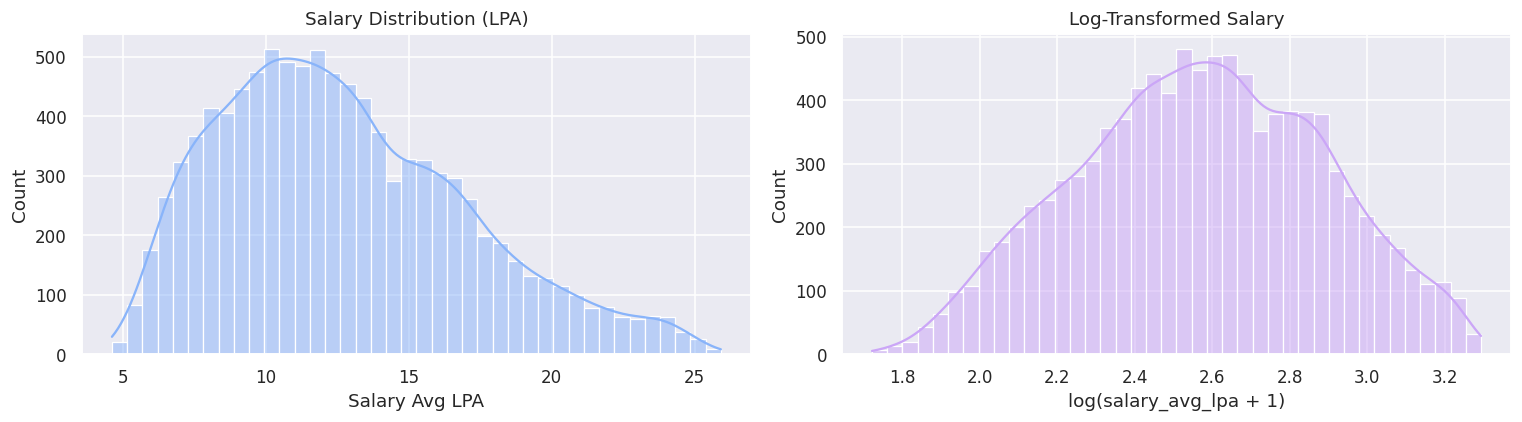

Skewness: 0.596  →  Symmetric enough, no transform needed


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: raw salary distribution
sns.histplot(df['salary_avg_lpa'], kde=True, bins=40,
            ax=axes[0], color='#89b4fa')
axes[0].set_title('Salary Distribution (LPA)')
axes[0].set_xlabel('Salary Avg LPA')

# Right: log-transformed salary
sns.histplot(np.log1p(df['salary_avg_lpa']), kde=True, bins=40,
            ax=axes[1], color='#cba6f7')
axes[1].set_title('Log-Transformed Salary')
axes[1].set_xlabel('log(salary_avg_lpa + 1)')

plt.tight_layout()
plt.show()

# Skewness score
skew = df['salary_avg_lpa'].skew()
print(f"Skewness: {skew:.3f}  →  {'Apply log transform ✓' if abs(skew)>1 else 'Symmetric enough, no transform needed'}")

               job_title  median   mean   std
0            ML Engineer   17.54  17.66  4.32
1         Data Scientist   16.30  16.61  4.33
2         Cloud Engineer   15.37  15.28  3.47
3        DevOps Engineer   13.63  13.76  3.12
4  Cybersecurity Analyst   12.96  12.87  3.20
5      Software Engineer   11.76  11.72  3.29
6      Backend Developer   11.40  11.32  2.91
7     Frontend Developer   10.11  10.01  2.49
8       Business Analyst    9.88   9.78  2.09
9           Data Analyst    8.18   8.24  1.78


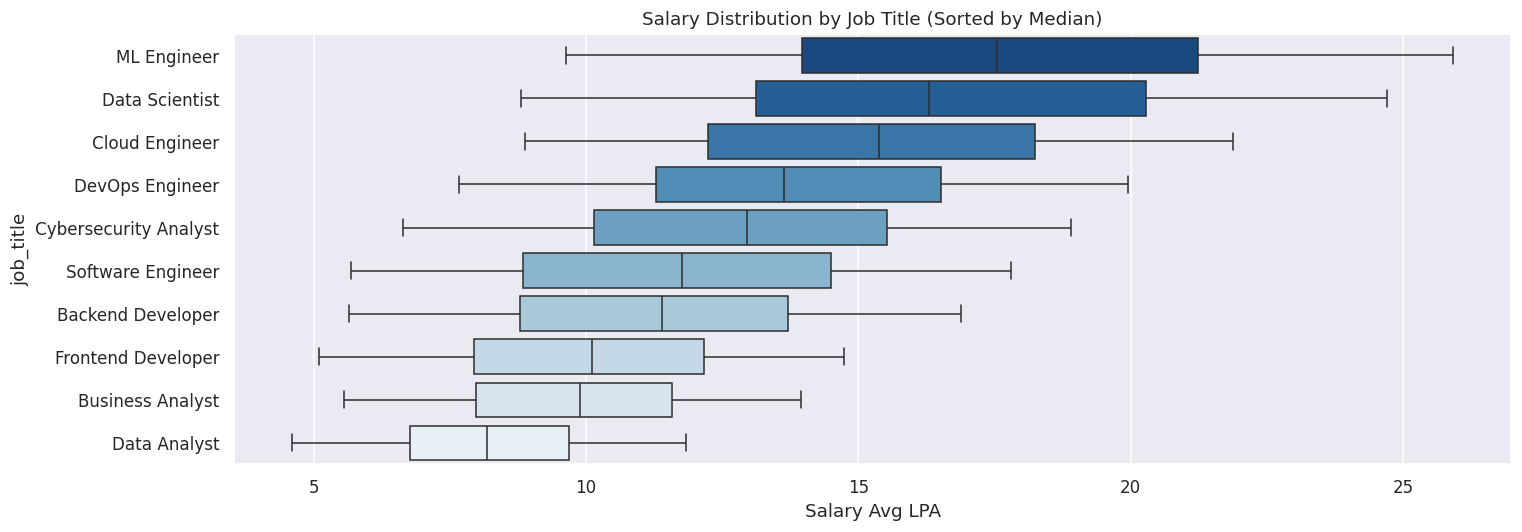

In [9]:
# Median salary per job title, sorted
role_salary = (
    df.groupby('job_title')['salary_avg_lpa']
    .agg(['median', 'mean', 'std'])
    .round(2)
    .sort_values('median', ascending=False)
    .reset_index()
)
print(role_salary)

# Boxplot: distribution + outliers per role
plt.figure(figsize=(14, 5))
sns.boxplot(
    data=df, x='salary_avg_lpa', y='job_title',
    order=role_salary['job_title'],   # sorted by median
    palette='Blues_r'
)
plt.title('Salary Distribution by Job Title (Sorted by Median)')
plt.xlabel('Salary Avg LPA')
plt.tight_layout()
plt.show()

In [10]:
loc_salary = (
    df.groupby('location')['salary_avg_lpa']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    loc_salary,
    x='location', y='salary_avg_lpa',
    color='salary_avg_lpa',
    color_continuous_scale='Teal',
    title='Median Salary by City (LPA)',
    text='salary_avg_lpa'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

In [11]:
# Interactive scatter — colour by job title
fig = px.scatter(
    df, x='experience_required_years', y='salary_avg_lpa',
    color='job_title',
    hover_data=['company_name', 'location', 'employment_type'],
    trendline='ols',
    opacity=0.5,
    title='Experience vs Salary — Coloured by Job Title'
)
fig.show()

# Per-role average salary at each experience band
exp_trend = df.groupby(['experience_required_years', 'job_title'])['salary_avg_lpa'].mean().reset_index()

fig2 = px.line(
    exp_trend, x='experience_required_years', y='salary_avg_lpa',
    color='job_title', markers=True,
    title='Average Salary by Experience Band and Role'
)
fig2.show()

# Pearson correlation
corr = df['experience_required_years'].corr(df['salary_avg_lpa'])
print(f"Experience ↔ Salary correlation: {corr:.3f}")

Experience ↔ Salary correlation: 0.004


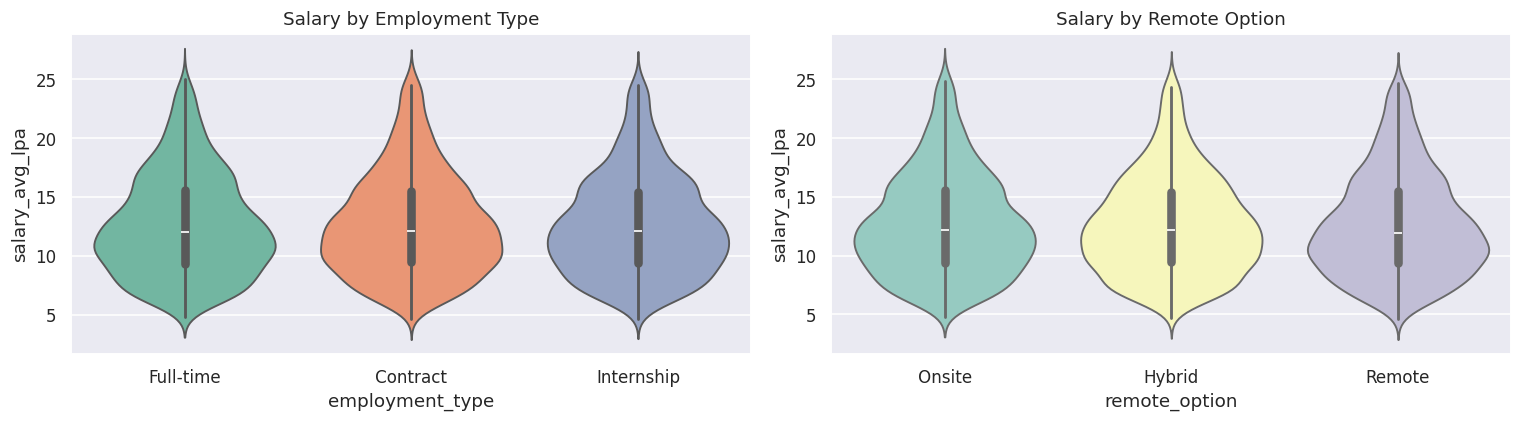


employment_type:
employment_type
Contract      12.16
Internship    12.13
Full-time     12.00
Name: salary_avg_lpa, dtype: float64

remote_option:
remote_option
Onsite    12.17
Hybrid    12.16
Remote    11.96
Name: salary_avg_lpa, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.violinplot(data=df, x='employment_type',
               y='salary_avg_lpa', ax=axes[0],
               order=['Full-time', 'Contract', 'Internship'],
               palette='Set2')
axes[0].set_title('Salary by Employment Type')

sns.violinplot(data=df, x='remote_option',
               y='salary_avg_lpa', ax=axes[1],
               order=['Onsite', 'Hybrid', 'Remote'],
               palette='Set3')
axes[1].set_title('Salary by Remote Option')

plt.tight_layout()
plt.show()

# Summary table
for col in ['employment_type', 'remote_option']:
    print(f"\n{col}:")
    print(df.groupby(col)['salary_avg_lpa'].median().round(2).sort_values(ascending=False))

In [13]:
# Explode the skills column into individual rows
df_skills = df[['salary_avg_lpa', 'skills']].copy()
df_skills['skills'] = df_skills['skills'].str.split(',')
df_skills = df_skills.explode('skills')
df_skills['skills'] = df_skills['skills'].str.strip()

# Median salary per skill
skill_salary = (
    df_skills.groupby('skills')['salary_avg_lpa']
    .agg(['median', 'count'])
    .query('count > 50')   # only skills with enough data
    .sort_values('median', ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    skill_salary, x='median', y='skills',
    orientation='h', color='median',
    color_continuous_scale='Purples',
    title='Top 15 Skills by Median Salary (LPA)'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

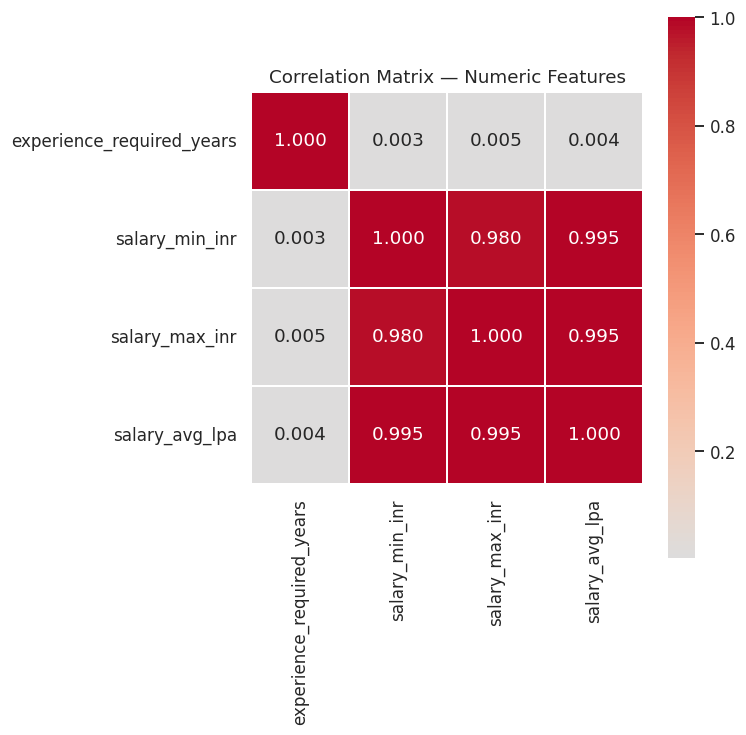

In [14]:
numeric_cols = ['experience_required_years', 'salary_min_inr',
                'salary_max_inr', 'salary_avg_lpa']

plt.figure(figsize=(7,7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.3f',
    cmap='coolwarm', center=0,
    square=True, linewidths=1
)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

Feature Engineering

In [15]:
# Drop columns we don't need for modelling
df_model = df.drop(columns=[
    'job_id',          # just a row number
    'skills',          # handled separately next step
    'salary_min_inr',  # data leakage: used to create target
    'salary_max_inr',  # same
    'salary_avg_inr'   # intermediate column, not needed
])

# Columns to one-hot encode
cat_cols = ['job_title', 'company_name', 'location',
            'employment_type', 'remote_option']

df_model = pd.get_dummies(df_model,
                           columns=cat_cols,
                           drop_first=True,
                           dtype=int)

print(f"Shape after encoding: {df_model.shape}")
print("New columns sample:", df_model.columns.tolist()[:10])

Shape after encoding: (10000, 31)
New columns sample: ['experience_required_years', 'salary_avg_lpa', 'job_title_Business Analyst', 'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Analyst', 'job_title_Data Scientist', 'job_title_DevOps Engineer', 'job_title_Frontend Developer', 'job_title_ML Engineer']


In [16]:
TOP_SKILLS = ['Python', 'SQL', 'AWS', 'Machine Learning',
              'Power BI', 'Tableau', 'Node.js', 'Azure',
              'Docker', 'React', 'Java', 'Kubernetes']

for skill in TOP_SKILLS:
    col_name = 'skill_' + skill.replace(' ', '_').lower()
    df_model[col_name] = df['skills'].str.contains(skill, case=False, na=False).astype(int)

print("Skill columns added:", [c for c in df_model.columns if c.startswith('skill_')])
print(f"Final shape: {df_model.shape}")

Skill columns added: ['skill_python', 'skill_sql', 'skill_aws', 'skill_machine_learning', 'skill_power_bi', 'skill_tableau', 'skill_node.js', 'skill_azure', 'skill_docker', 'skill_react', 'skill_java', 'skill_kubernetes']
Final shape: (10000, 43)


In [17]:
# Check skewness again after confirming target column
skew_val = df_model['salary_avg_lpa'].skew()
print(f"Skewness: {skew_val:.3f}")

# Apply log transform if skewed
USE_LOG = abs(skew_val) > 1

if USE_LOG:
    df_model['target'] = np.log1p(df_model['salary_avg_lpa'])
    print("✓ Using log-transformed target")
else:
    df_model['target'] = df_model['salary_avg_lpa']
    print("✓ Using raw salary target")

Skewness: 0.596
✓ Using raw salary target


Scale Features & Train/Test Split

In [18]:
# Define features (X) and target (y)
X = df_model.drop(columns=['salary_avg_lpa', 'target'])
y = df_model['target']

print(f"Features: {X.shape[1]} columns | Samples: {X.shape[0]}")

# Train/Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

# Scale features (fit on train only — never on full data)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # learn mean/std from train, apply
X_test_sc  = scaler.transform(X_test)        # apply same scale to test (no re-fitting)

Features: 42 columns | Samples: 10000
Train: 8000 rows | Test: 2000 rows


Model Building

In [19]:
# Helper function — reuse for every model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, log_target=False):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if log_target:         # reverse log transform for human-readable errors
        y_te_r  = np.expm1(y_te)
        y_pred_r = np.expm1(y_pred)
    else:
        y_te_r, y_pred_r = y_te, y_pred

    mae  = mean_absolute_error(y_te_r, y_pred_r)
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
    r2   = r2_score(y_te_r, y_pred_r)

    print(f"── {name} ──────────────────────")
    print(f"  MAE  : {mae:.2f} LPA")
    print(f"  RMSE : {rmse:.2f} LPA")
    print(f"  R²   : {r2:.4f}")
    return {'Model':name, 'MAE':round(mae,2), 'RMSE':round(rmse,2), 'R2':round(r2,4), 'model_obj':model}

# Fit and evaluate
results = []
lr_result = evaluate_model('Linear Regression', LinearRegression(),
                             X_train_sc, X_test_sc, y_train, y_test, USE_LOG)
results.append(lr_result)

── Linear Regression ──────────────────────
  MAE  : 2.69 LPA
  RMSE : 3.22 LPA
  R²   : 0.4501


In [20]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV tries multiple alpha values and picks the best via cross-validation
alphas = [0.01, 0.1, 1, 10, 100]

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_result = evaluate_model('Ridge (CV)', ridge_cv,
                               X_train_sc, X_test_sc, y_train, y_test, USE_LOG)
results.append(ridge_result)
print(f"Best Ridge alpha: {ridge_cv.alpha_}")

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_sc, y_train)
lasso_result = evaluate_model('Lasso (CV)', lasso_cv,
                               X_train_sc, X_test_sc, y_train, y_test, USE_LOG)
results.append(lasso_result)
print(f"Best Lasso alpha: {lasso_cv.alpha_}")

# Count features zeroed out by Lasso
n_zero = (lasso_cv.coef_ == 0).sum()
print(f"Features zeroed by Lasso: {n_zero}/{X.shape[1]}")

── Ridge (CV) ──────────────────────
  MAE  : 2.69 LPA
  RMSE : 3.22 LPA
  R²   : 0.4501
Best Ridge alpha: 10.0
── Lasso (CV) ──────────────────────
  MAE  : 2.69 LPA
  RMSE : 3.22 LPA
  R²   : 0.4506
Best Lasso alpha: 0.01
Features zeroed by Lasso: 12/42


In [21]:
# Use unscaled features for RF (it's scale-invariant)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,          # trees grow fully by default
    min_samples_split=5,
    random_state=42,
    n_jobs=-1               # use all CPU cores in parallel
)

rf_result = evaluate_model('Random Forest (200 trees)', rf,
                            X_train, X_test, y_train, y_test, USE_LOG)
results.append(rf_result)

# 5-fold cross-validation score
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"\nCV R² scores : {cv_scores.round(3)}")
print(f"Mean CV R²   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

── Random Forest (200 trees) ──────────────────────
  MAE  : 2.72 LPA
  RMSE : 3.29 LPA
  R²   : 0.4276

CV R² scores : [0.417 0.42  0.422 0.426 0.415]
Mean CV R²   : 0.420 ± 0.004


In [22]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,              # 3-fold to keep runtime manageable
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best params : {grid_search.best_params_}")
print(f"Best CV R²  : {grid_search.best_score_:.4f}")

# Evaluate the best model
rf_best = grid_search.best_estimator_
rf_tuned_result = evaluate_model('RF Tuned', rf_best,
                                  X_train, X_test, y_train, y_test, USE_LOG)
results.append(rf_tuned_result)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best CV R²  : 0.4379
── RF Tuned ──────────────────────
  MAE  : 2.70 LPA
  RMSE : 3.24 LPA
  R²   : 0.4445


In [23]:
# Build comparison DataFrame from collected results
compare_df = pd.DataFrame([{'Model':r['Model'],'MAE':r['MAE'],
                              'RMSE':r['RMSE'],'R2':r['R2']} for r in results])
compare_df = compare_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(compare_df.to_string(index=False))

# Bar chart comparison
fig = px.bar(
    compare_df, x='Model', y='R2',
    color='R2', color_continuous_scale='Greens',
    text='R2', title='Model R² Comparison'
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.show()

                    Model  MAE  RMSE     R2
               Lasso (CV) 2.69  3.22 0.4506
        Linear Regression 2.69  3.22 0.4501
               Ridge (CV) 2.69  3.22 0.4501
                 RF Tuned 2.70  3.24 0.4445
Random Forest (200 trees) 2.72  3.29 0.4276


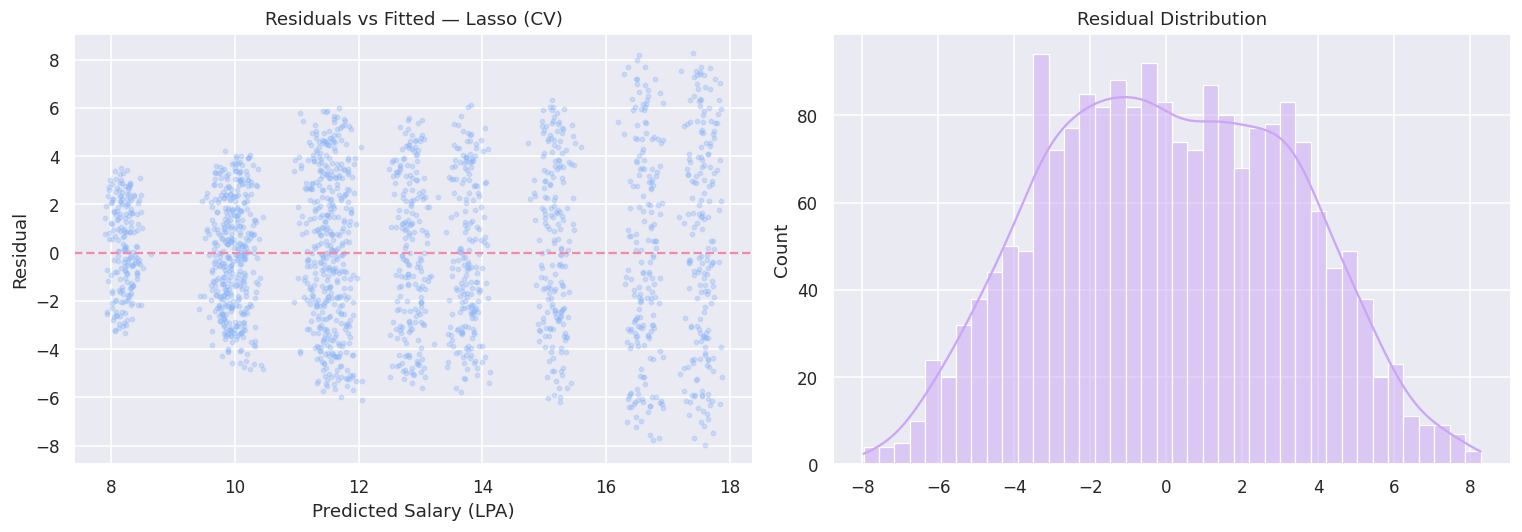

In [24]:
best_model_name = compare_df.iloc[0]['Model']
best_result     = [r for r in results if r['Model']==best_model_name][0]
best_obj        = best_result['model_obj']

# Generate predictions (use unscaled X_test if RF won, scaled if linear won)
is_rf = 'Forest' in best_model_name
X_eval = X_test if is_rf else X_test_sc
y_pred_best = best_obj.predict(X_eval)

if USE_LOG:
    y_actual = np.expm1(y_test.values)
    y_pred_best = np.expm1(y_pred_best)
else:
    y_actual = y_test.values

residuals = y_actual - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=8, color='#89b4fa')
axes[0].axhline(0, color='#f38ba8', lw=1.5, ls='--')
axes[0].set_xlabel('Predicted Salary (LPA)')
axes[0].set_ylabel('Residual')
axes[0].set_title(f'Residuals vs Fitted — {best_model_name}')

sns.histplot(residuals, kde=True, bins=40, ax=axes[1], color='#cba6f7')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

In [25]:
# Random Forest feature importance
feat_imp = pd.Series(
    rf_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

fig = px.bar(
    x=feat_imp.values, y=feat_imp.index,
    orientation='h',
    title='Top 20 Features — Random Forest Importance',
    labels={'x':'Importance Score', 'y':'Feature'},
    color=feat_imp.values, color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=550)
fig.show()

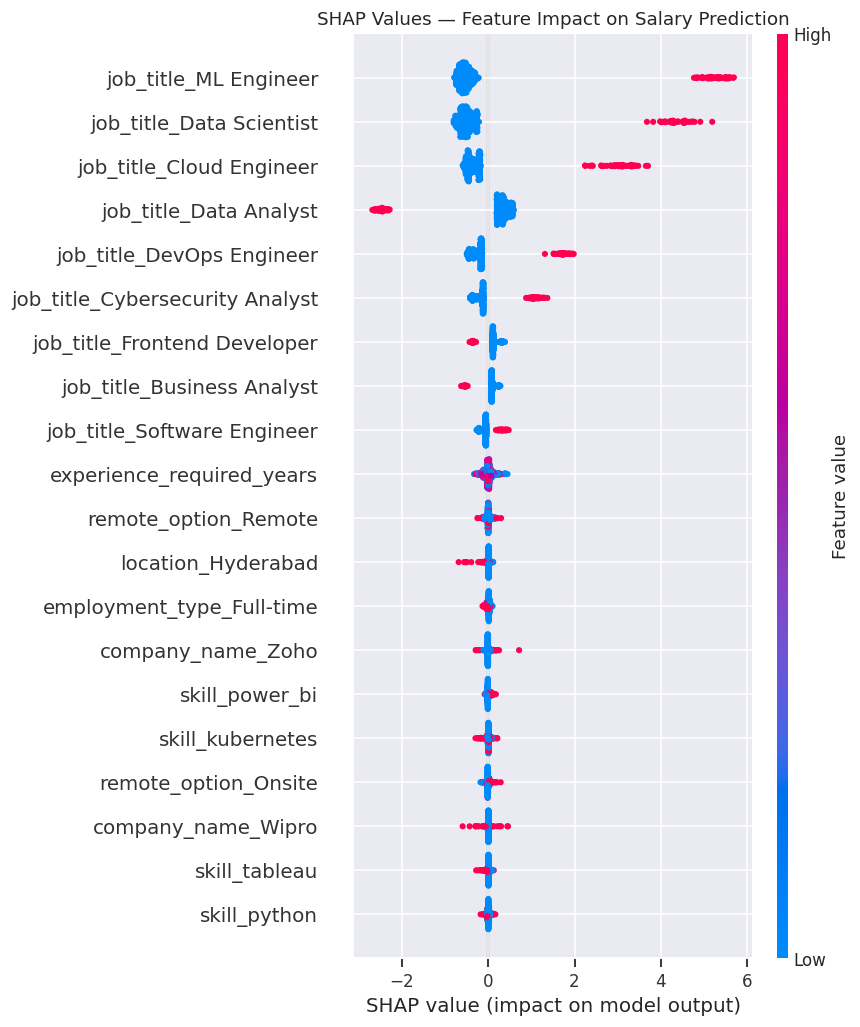

In [26]:
# Use a 500-row sample for SHAP speed (still representative at 10k rows)
X_sample = X_test.sample(500, random_state=42)

explainer  = shap.TreeExplainer(rf_best)
shap_vals  = explainer.shap_values(X_sample)

# Beeswarm plot: each dot = one prediction
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_sample, plot_type='dot', show=False)
plt.title('SHAP Values — Feature Impact on Salary Prediction')
plt.tight_layout()
plt.show()

In [27]:
# Overall trend: all roles combined
trend_overall = (
    df.groupby('experience_required_years')['salary_avg_lpa']
    .mean().reset_index()
)

# Per-role trend
trend_by_role = (
    df.groupby(['experience_required_years', 'job_title'])['salary_avg_lpa']
    .mean().reset_index()
)

fig = px.line(
    trend_by_role,
    x='experience_required_years', y='salary_avg_lpa',
    color='job_title', markers=True,
    title='Salary Trend by Experience — All Job Titles (Current Data)',
    labels={'experience_required_years': 'Years of Experience',
            'salary_avg_lpa': 'Avg Salary (LPA)'}
)
fig.show()

In [28]:
from itertools import product

# Experience range to project (0-20, i.e. 5 years beyond current max)
future_exp    = list(range(0, 21))
future_titles = df['job_title'].unique().tolist()

# Build all combinations of experience × job title
future_rows = []
for exp, title in product(future_exp, future_titles):
    future_rows.append({
        'experience_required_years': exp,
        'job_title'  : title,
        'company_name'     : 'TCS',           # baseline company
        'location'         : 'Bangalore',     # baseline city
        'employment_type'  : 'Full-time',
        'remote_option'    : 'Hybrid',
        'skills'           : 'Python, SQL, AWS'  # baseline skill set
    })

df_future = pd.DataFrame(future_rows)
print(f"Future projection rows: {len(df_future)}")  # 21 exp × 10 titles = 210

# Apply same encoding and skill features as training data
df_future_enc = pd.get_dummies(df_future.drop(columns=['skills']),
                                columns=cat_cols, drop_first=True, dtype=int)

for skill in TOP_SKILLS:
    col_name = 'skill_' + skill.replace(' ','_').lower()
    df_future_enc[col_name] = df_future['skills'].str.contains(skill, case=False, na=False).astype(int)

# Align columns with training set (fill any missing with 0)
df_future_enc = df_future_enc.reindex(columns=X_train.columns, fill_value=0)
print("Future feature matrix ready ✓")

Future projection rows: 210
Future feature matrix ready ✓


In [29]:
# Get point prediction from best RF model
future_preds = rf_best.predict(df_future_enc)
if USE_LOG:
    future_preds = np.expm1(future_preds)

# Uncertainty estimate: std across individual tree predictions
tree_preds = np.array([tree.predict(df_future_enc) for tree in rf_best.estimators_])
if USE_LOG:
    tree_preds = np.expm1(tree_preds)
pred_std = tree_preds.std(axis=0)

# Attach predictions to future DataFrame
df_future['predicted_lpa'] = future_preds.round(2)
df_future['pred_lower']    = (future_preds - 1.96 * pred_std).round(2)
df_future['pred_upper']    = (future_preds + 1.96 * pred_std).round(2)

# Plot projections with confidence bands per role
fig = go.Figure()

for title in df['job_title'].unique():
    sub = df_future[df_future['job_title']==title].sort_values('experience_required_years')
    fig.add_trace(go.Scatter(
        x=sub['experience_required_years'], y=sub['predicted_lpa'],
        name=title, mode='lines+markers'
    ))
    fig.add_trace(go.Scatter(
        x=pd.concat([sub['experience_required_years'], sub['experience_required_years'][::-1]]),
        y=pd.concat([sub['pred_upper'], sub['pred_lower'][::-1]]),
        fill='toself', opacity=0.1, showlegend=False,
        line=dict(width=0), name=title+' CI'
    ))

fig.update_layout(title='Salary Projection by Experience Year — All Job Titles',
                  xaxis_title='Years of Experience',
                  yaxis_title='Projected Salary (LPA)')
fig.show()

In [30]:
def project_scenario(job_title, location, emp_type, remote, skills_str):
    """Returns predicted salary at each experience level for one scenario."""
    rows = [{
        'experience_required_years': exp,
        'job_title': job_title, 'company_name': 'TCS',
        'location': location, 'employment_type': emp_type,
        'remote_option': remote, 'skills': skills_str
    } for exp in range(0, 21)]
    df_s = pd.DataFrame(rows)
    df_enc = pd.get_dummies(df_s.drop(columns=['skills']),
                             columns=cat_cols, drop_first=True, dtype=int)
    for skill in TOP_SKILLS:
        cn = 'skill_'+skill.replace(' ','_').lower()
        df_enc[cn] = df_s['skills'].str.contains(skill, case=False, na=False).astype(int)
    df_enc = df_enc.reindex(columns=X_train.columns, fill_value=0)
    preds = rf_best.predict(df_enc)
    if USE_LOG: preds = np.expm1(preds)
    return list(range(0, 21)), preds

# Define scenarios for Data Scientist
scenarios = {
    'DS · Bangalore · Full-time · Onsite'   : ('Data Scientist', 'Bangalore',  'Full-time', 'Onsite',  'Python, AWS, Machine Learning'),
    'DS · Noida · Full-time · Onsite'       : ('Data Scientist', 'Noida',      'Full-time', 'Onsite',  'Python, AWS, Machine Learning'),
    'DS · Bangalore · Contract · Remote'    : ('Data Scientist', 'Bangalore',  'Contract', 'Remote',  'Python, AWS, Machine Learning'),
    'ML Eng · Bangalore · Full-time · Hybrid': ('ML Engineer',   'Bangalore',  'Full-time', 'Hybrid', 'Python, Machine Learning, Docker'),
}

fig = go.Figure()
for label, params in scenarios.items():
    exp_range, preds = project_scenario(*params)
    fig.add_trace(go.Scatter(x=exp_range, y=preds, name=label, mode='lines+markers'))

fig.update_layout(
    title='Scenario Analysis — Salary Projection by Role / City / Contract Type',
    xaxis_title='Years of Experience',
    yaxis_title='Projected Salary (LPA)',
    height=480
)
fig.show()